In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

data = {
    'Quarter': ['Q1-2021','Q2-2021','Q3-2021','Q4-2021','Q1-2022','Q2-2022','Q3-2022','Q4-2022','Q1-2023','Q2-2023',
                'Q3-2023','Q4-2023','Q1-2024','Q2-2024','Q3-2024','Q4-2024','Q1-2025','Q2-2025','Q3-2025','Q4-2025'],
    'ARPU': [145, 146, 153, 163, 178, 183, 190, 193, 200, 203, 208, 211, 215, 218, 223, 245.3, 245.0, 250.3, 255.7, 258.6],
    'Subscribers': [321, 323, 323.5, 326, 326, 327, 328, 332, 335, 338, 342, 345, 348, 352, 354, 356.6, 361.6, 362.8, 364.2, 368.5]
}
df = pd.DataFrame(data)


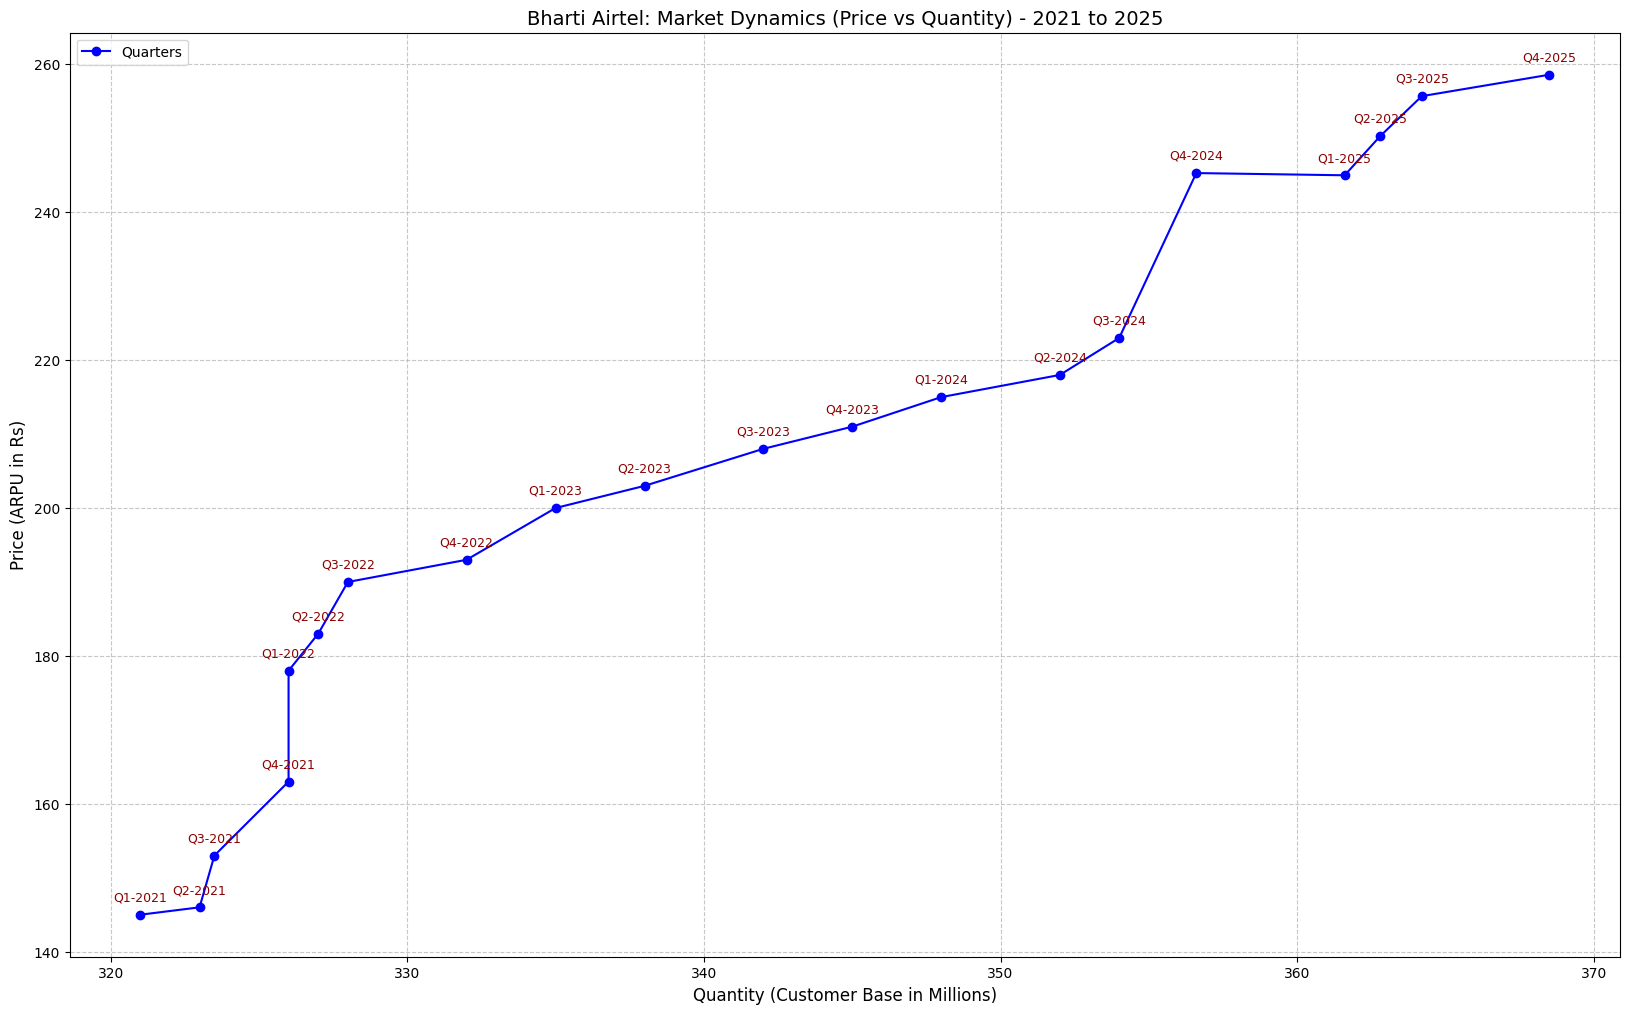

In [27]:

plt.figure(figsize=(20, 12)) 


plt.plot(df['Subscribers'], df['ARPU'], marker='o', linestyle='-', color='b', label='Quarters')

plt.xlabel('Quantity (Customer Base in Millions)', fontsize=12)
plt.ylabel('Price (ARPU in Rs)', fontsize=12)
plt.title('Bharti Airtel: Market Dynamics (Price vs Quantity) - 2021 to 2025', fontsize=14)


for i, txt in enumerate(df['Quarter']):
    plt.annotate(txt, 
                 (df['Subscribers'][i], df['ARPU'][i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9,
                 color='darkred') 
    
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

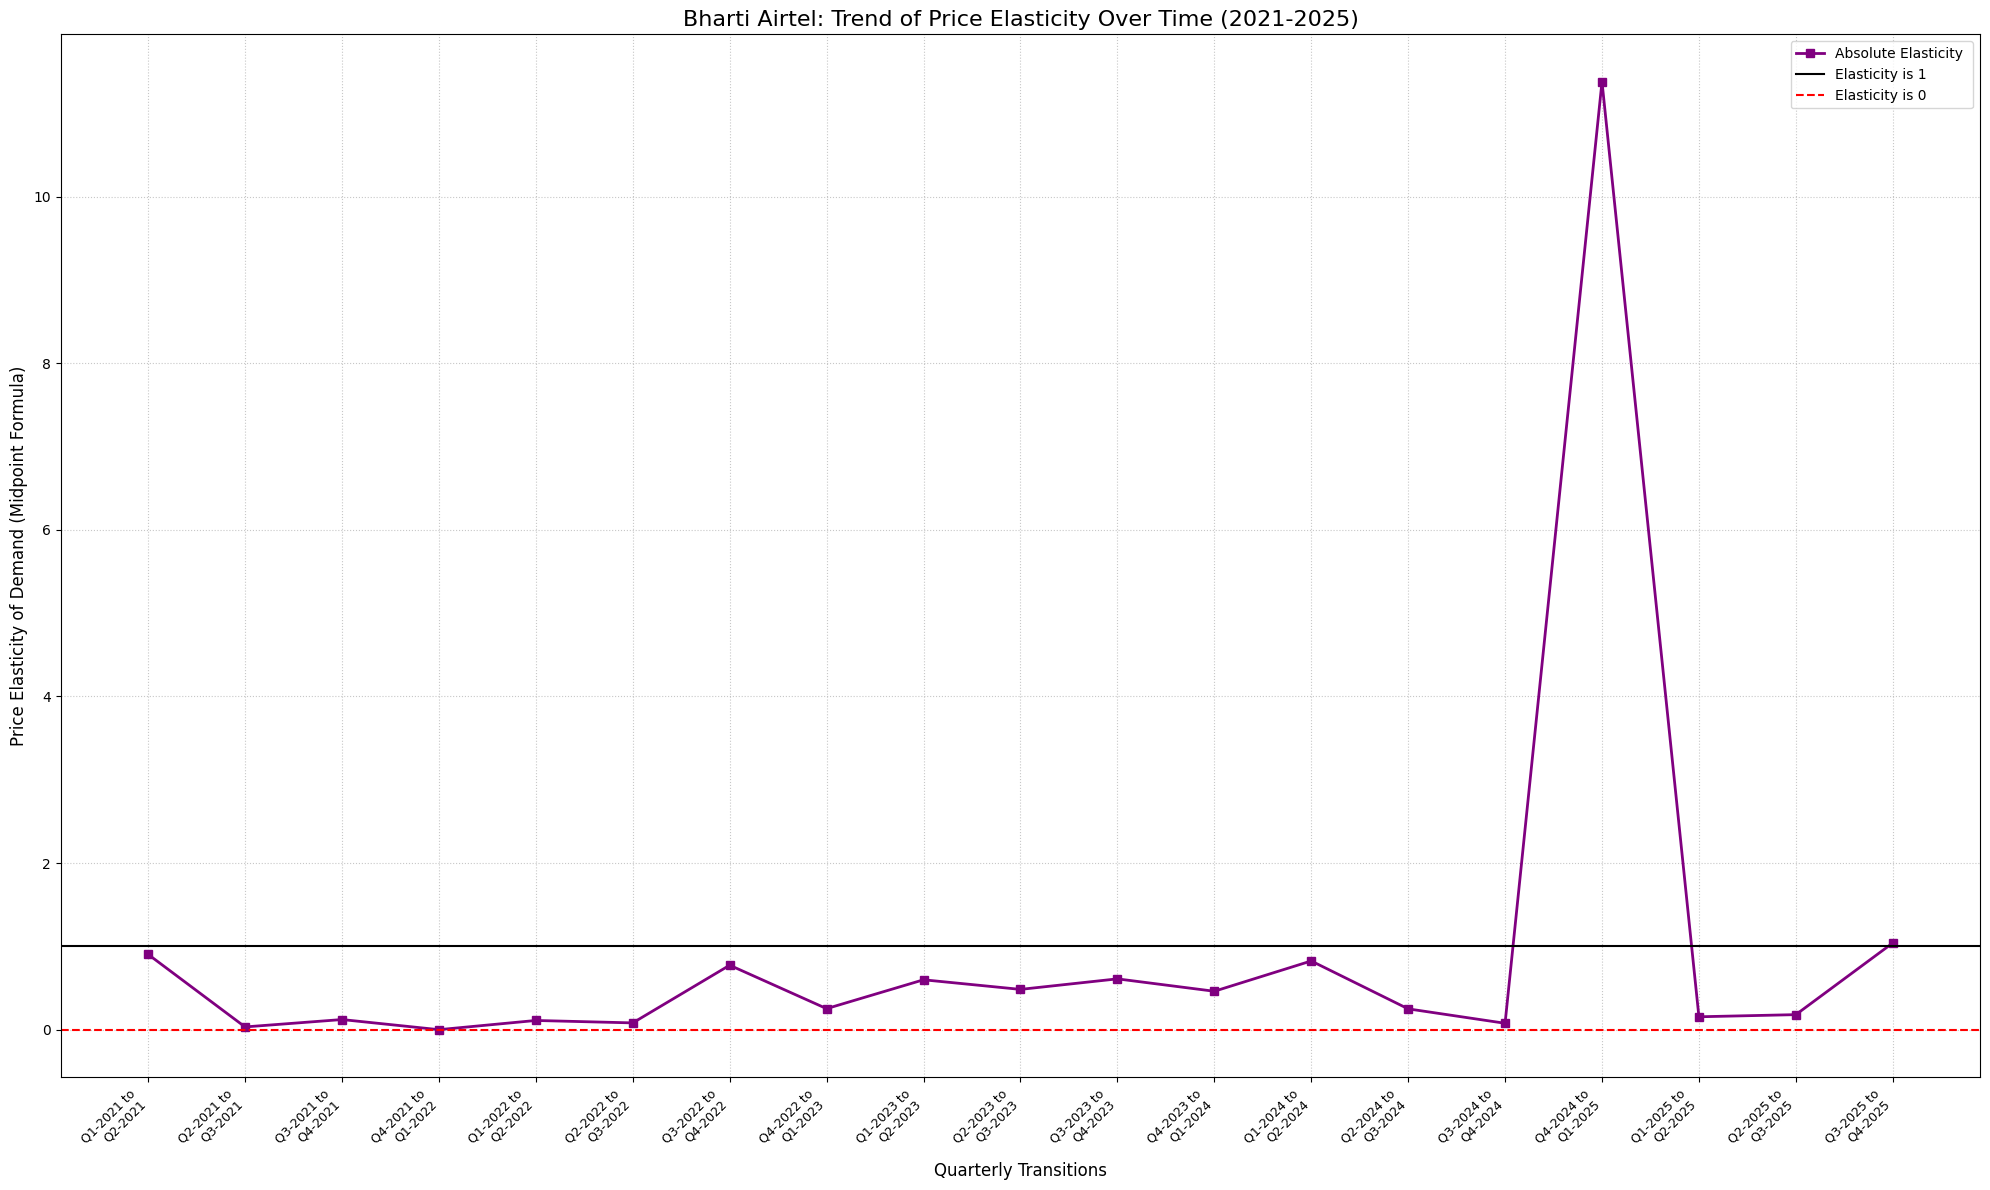

In [29]:

elasticities = []
period_labels = []


for i in range(1, len(df)):
    Q1, Q2 = df['Subscribers'][i-1], df['Subscribers'][i]
    P1, P2 = df['ARPU'][i-1], df['ARPU'][i]
    
    pct_change_Q = (Q2 - Q1) / ((Q1 + Q2) / 2)
    pct_change_P = (P2 - P1) / ((P1 + P2) / 2)
    

    if pct_change_P == 0:
        ed = np.nan 
    else:
        ed = pct_change_Q / pct_change_P
        
    elasticities.append(abs(ed))
    
    period_labels.append(f"{df['Quarter'][i-1]} to\n{df['Quarter'][i]}")

ed_df = pd.DataFrame({'Period': period_labels, 'Elasticity': elasticities})


plt.figure(figsize=(20, 12))

plt.plot(ed_df['Period'], ed_df['Elasticity'], marker='s', linestyle='-', color='purple', linewidth=2, label='Absolute Elasticity ')
plt.axhline(1, color='black', linewidth=1.5, label='Elasticity is 1')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Elasticity is 0')

plt.xlabel('Quarterly Transitions', fontsize=12)
plt.ylabel('Price Elasticity of Demand (Midpoint Formula)', fontsize=12)
plt.title('Bharti Airtel: Trend of Price Elasticity Over Time (2021-2025)', fontsize=16)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/mw/zgv_k_zn6lvfvk3fvk8c_04h0000gn/T/ipykernel_30173/3876830879.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df['Quarter'], rotation=45, ha='right')


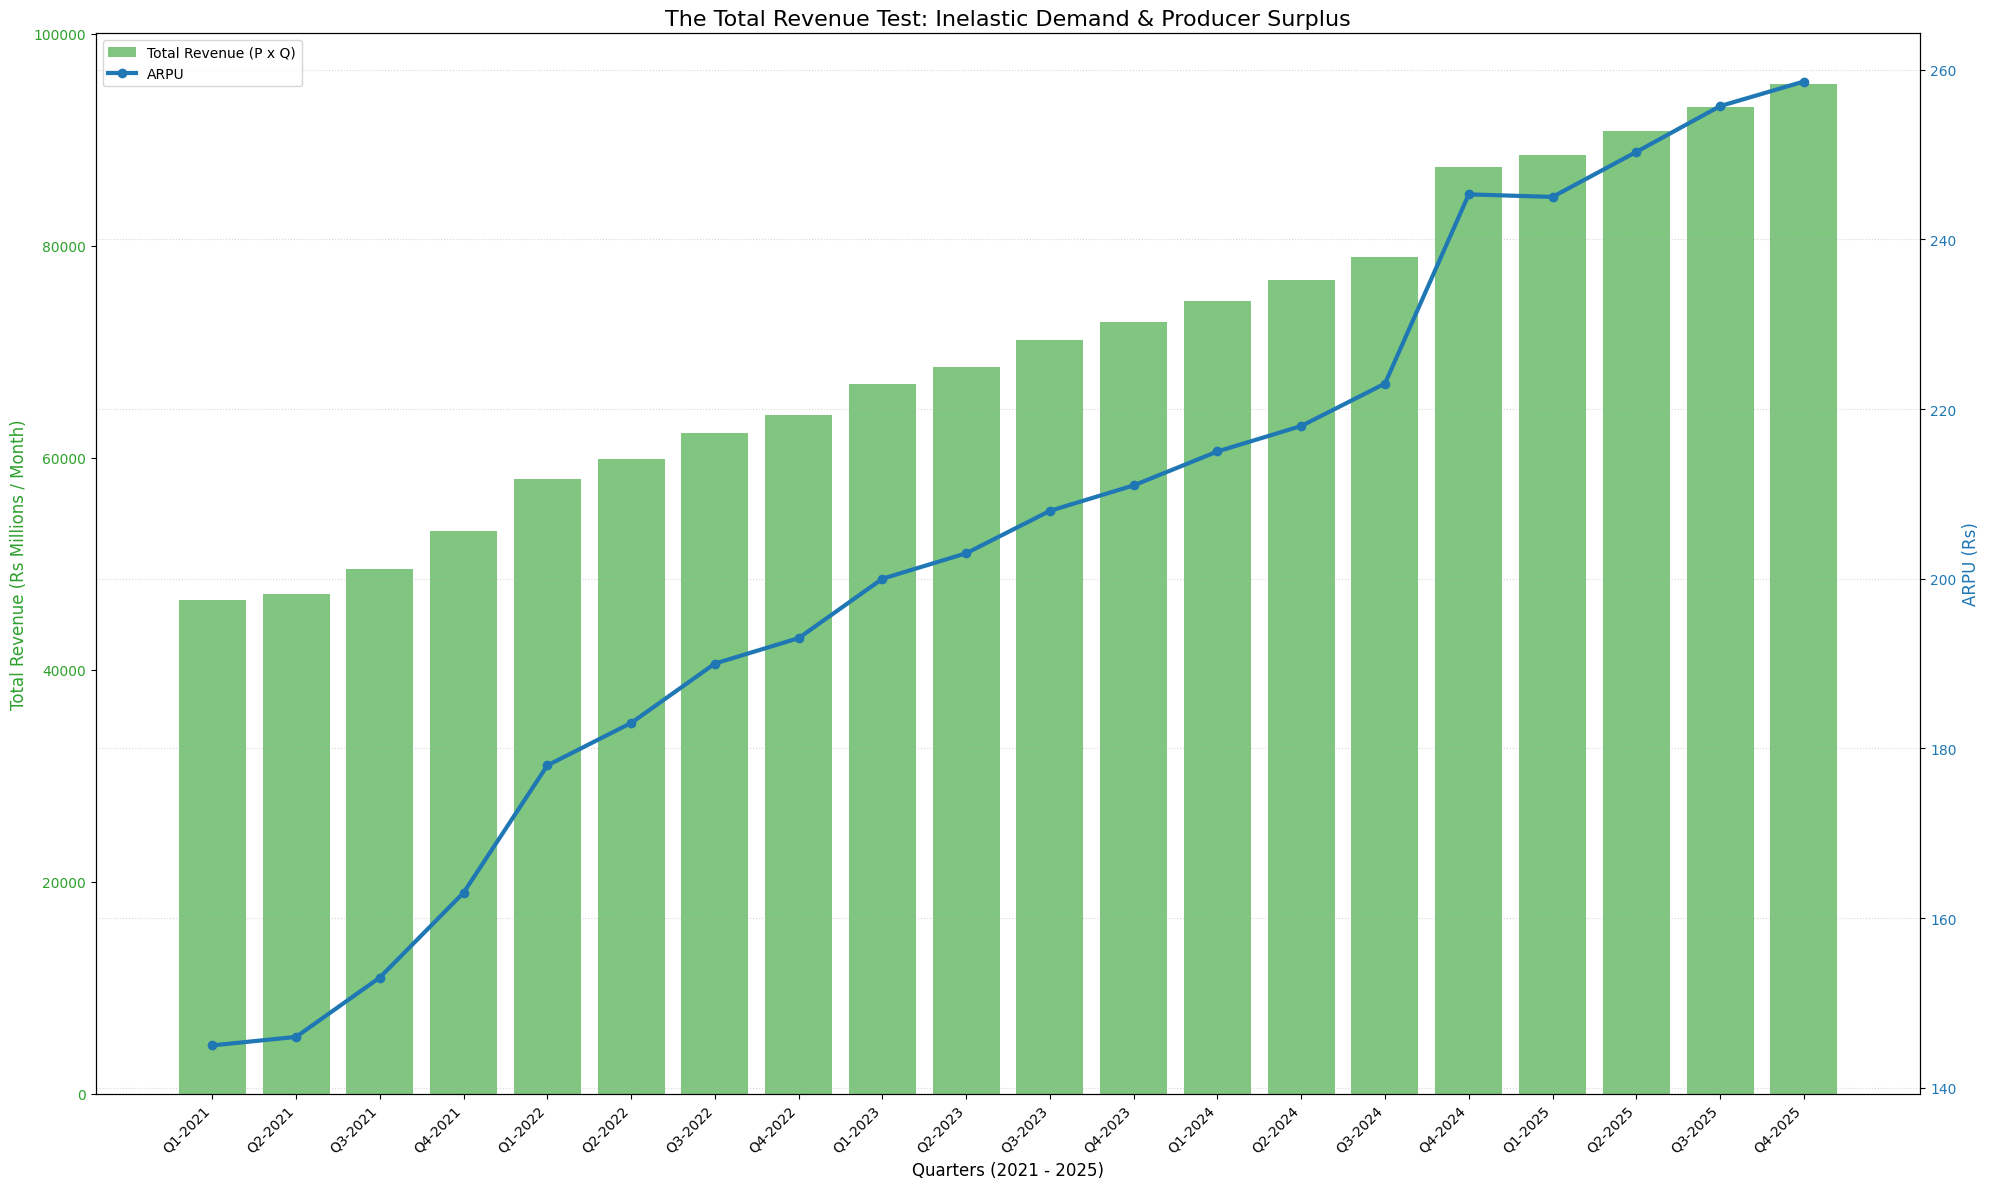

In [24]:

df['Total_Revenue'] = df['ARPU'] * df['Subscribers']

fig, ax1 = plt.subplots(figsize=(20, 12))

color = 'tab:green'
ax1.set_xlabel('Quarters (2021 - 2025)', fontsize=12)
ax1.set_ylabel('Total Revenue (Rs Millions / Month)', color=color, fontsize=12)
bars = ax1.bar(df['Quarter'], df['Total_Revenue'], color=color, alpha=0.6, label='Total Revenue (P x Q)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(df['Quarter'], rotation=45, ha='right')


ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('ARPU (Rs)', color=color, fontsize=12)  
line = ax2.plot(df['Quarter'], df['ARPU'], color=color, marker='o', linewidth=3, label='ARPU')
ax2.tick_params(axis='y', labelcolor=color)


plt.title('The Total Revenue Test: Inelastic Demand & Producer Surplus', fontsize=16)
fig.tight_layout()  
plt.grid(True, linestyle=':', alpha=0.5)


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show();